# ExtraaLearn — Potential Customers Prediction

## Context

The EdTech industry has been surging over the past decade immensely, and according to a forecast, the Online Education market would be worth **\$286.62 billion by 2023** with a compound annual growth rate (CAGR) of **10.26 %** from 2018 to 2023. Modern online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc., it is now preferable to traditional education.

In the present scenario due to Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as **leads**. There are various sources of obtaining leads for EdTech companies, like:

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure.
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

**ExtraaLearn** is an initial-stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill / reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. As a data scientist at ExtraaLearn, we have been provided the leads data to:

1. **Analyze and build an ML model** to help identify which leads are more likely to convert to paid customers.
2. **Find the factors** driving the lead conversion process.
3. **Create a profile** of the leads which are likely to convert.

---

## Data Dictionary

| Variable | Description |
|----------|-------------|
| **ID** | Lead identifier |
| **age** | Age of the lead |
| **current_occupation** | Current occupation — `Professional`, `Unemployed`, `Student` |
| **first_interaction** | How the lead first interacted — `Website`, `Mobile App` |
| **profile_completed** | Percentage of profile filled — `Low` (0–50 %), `Medium` (50–75 %), `High` (75–100 %) |
| **website_visits** | Number of website visits |
| **time_spent_on_website** | Total time (seconds) on the website |
| **page_views_per_visit** | Average pages viewed per visit |
| **last_activity** | Last interaction type — Email / Phone / Website Activity |
| **print_media_type1** | Flag — saw ad in Newspaper |
| **print_media_type2** | Flag — saw ad in Magazine |
| **digital_media** | Flag — saw ad on digital platforms |
| **educational_channels** | Flag — heard via education channels (forums, threads, educational sites) |
| **referral** | Flag — heard through referral |
| **status** | Target — `1` = converted, `0` = not converted |

## Importing necessary libraries and data

In [54]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Misc  # Dada Loves RekhaRoy — and today we love clean data just as much!
import warnings
warnings.filterwarnings('ignore')

# Aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [55]:
# Load the dataset
df = pd.read_csv('../data/raw/datasets.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 4612 rows x 15 columns


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


## Data Overview

Let's examine the structure and quality of our dataset.

In [56]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [57]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [58]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

Total missing values: 0


In [59]:
# Check for duplicate rows (excluding ID)
dupes = df.drop(columns='ID').duplicated().sum()
print(f'Duplicate rows (excluding ID): {dupes}')

Duplicate rows (excluding ID): 14


In [60]:
# Quick look at the target variable distribution
print('Target variable (status) distribution:')
print(df['status'].value_counts())
print(f'\nConversion rate: {df["status"].mean():.1%}')

Target variable (status) distribution:
status
0    3235
1    1377
Name: count, dtype: int64

Conversion rate: 29.9%


### Observations — Data Overview

- The dataset contains **4,612 leads** with **15 features** (including the target).
- There are **no missing values** and **no duplicate rows** — the data is clean.
- **4 numerical features**: `age`, `website_visits`, `time_spent_on_website`, `page_views_per_visit`.
- **9 categorical features**: occupation, interaction channels, media flags, etc.
- **1 target variable**: `status` — binary (0/1).
- The overall conversion rate is about **29.9 %**, meaning roughly 3 in 10 leads convert.
- `time_spent_on_website` has high variance (std ≈ 744) and a right-skewed distribution (mean 724 vs median ~376).
- `website_visits` has a max of 30, which might be an outlier worth investigating.

## Exploratory Data Analysis (EDA)

EDA is a crucial step. We'll start with univariate analysis to understand each variable, then move to bivariate analysis to see how features relate to the target variable `status`.

### Univariate Analysis — Numerical Features

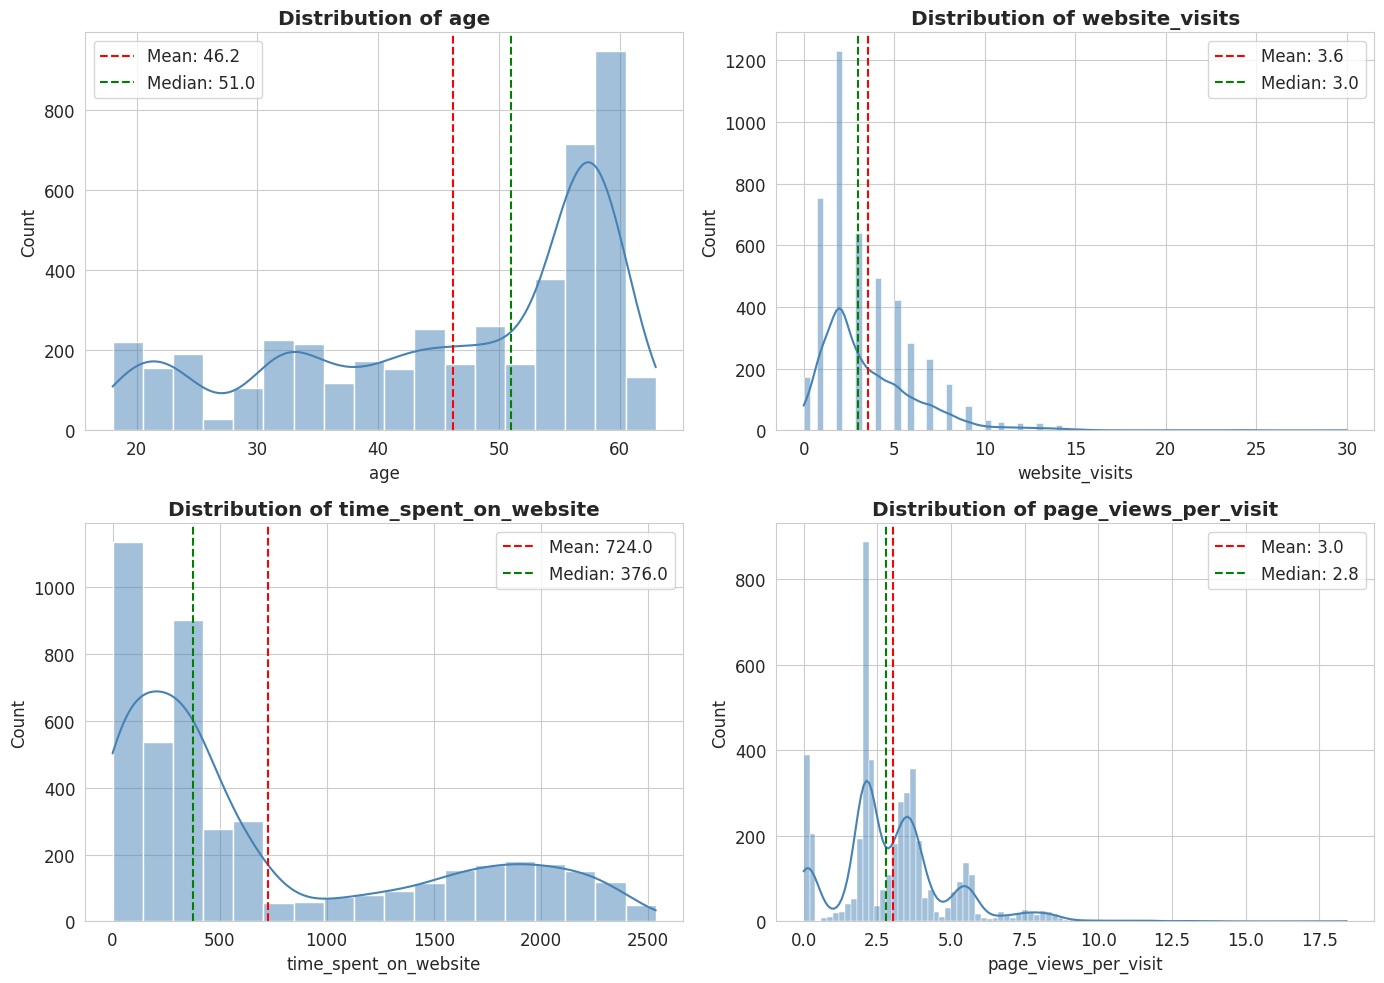

In [61]:
numerical_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(numerical_cols):
    ax = axes[i // 2][i % 2]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

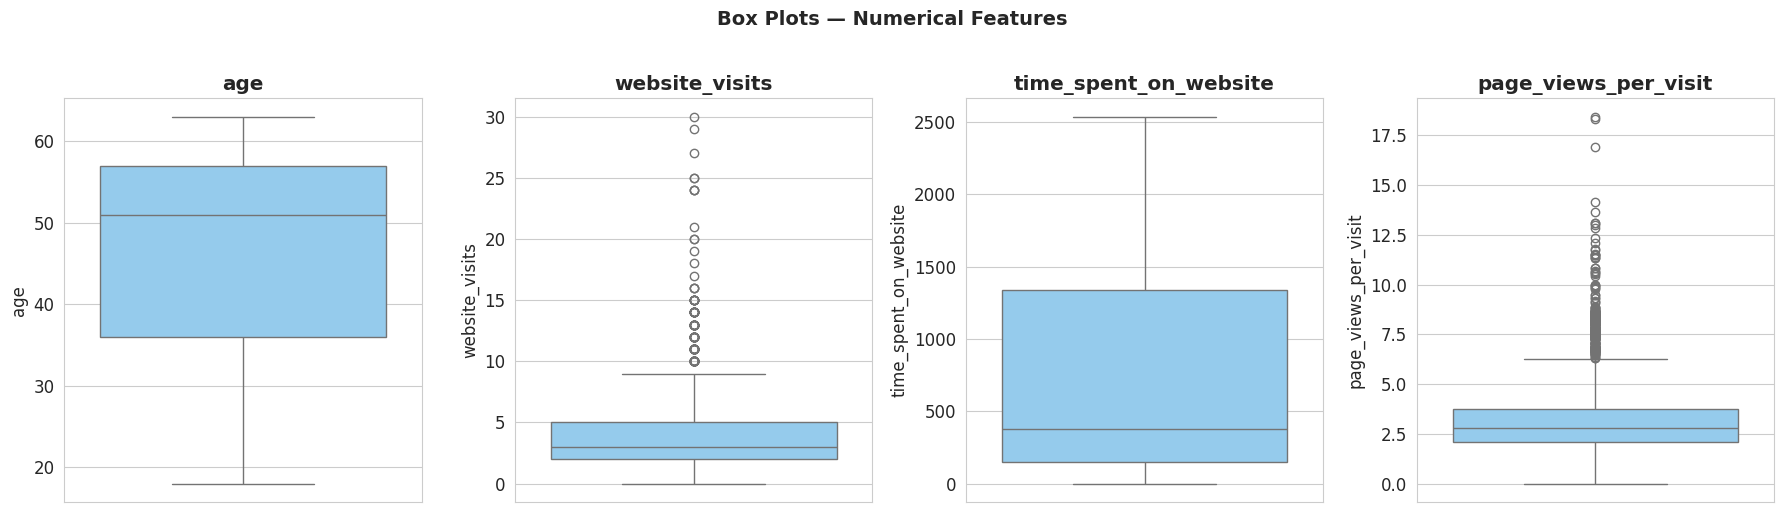

In [62]:
# Box plots to identify outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightskyblue')
    axes[i].set_title(f'{col}', fontweight='bold')

plt.suptitle('Box Plots — Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observations — Numerical Features

- **age**: Left-skewed (median 51 > mean 46). Range 18–63. No extreme outliers, but the distribution is concentrated in the 35–60 range.
- **website_visits**: Right-skewed with most leads visiting 0–5 times. A few outliers visit up to 30 times.
- **time_spent_on_website**: Strongly right-skewed (median 376 vs mean 724). Many leads spend very little time; some spend up to ~2,500 seconds.
- **page_views_per_visit**: Right-skewed with a long tail. Most leads view 0–5 pages per visit; a few outliers go above 10.

### Univariate Analysis — Categorical Features

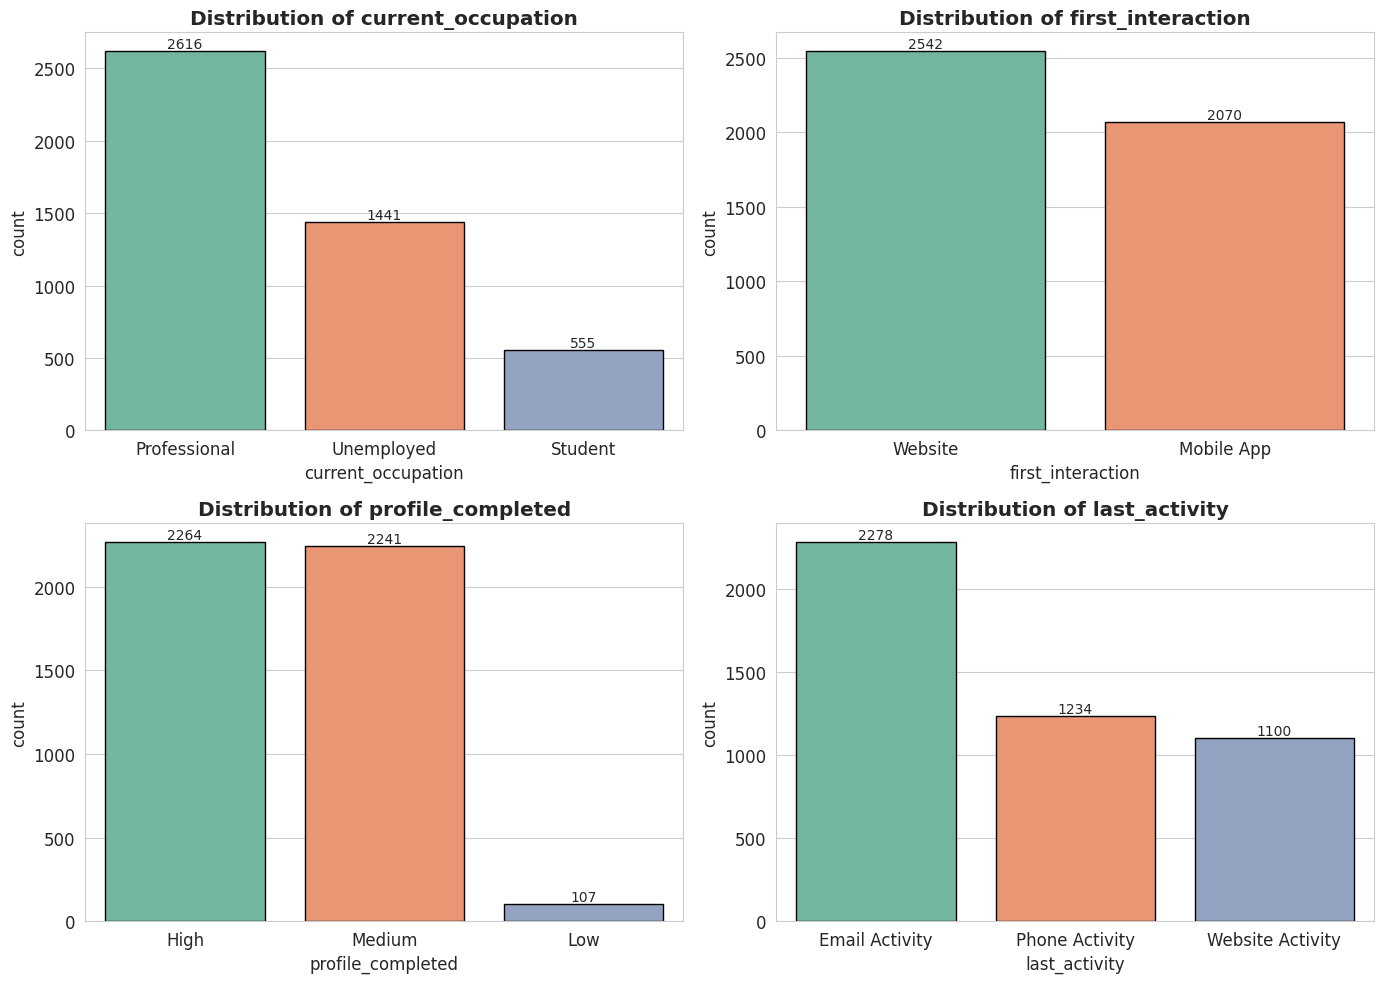

In [63]:
categorical_cols = ['current_occupation', 'first_interaction', 'profile_completed',
                    'last_activity']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(categorical_cols):
    ax = axes[i // 2][i % 2]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order, palette='Set2', edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

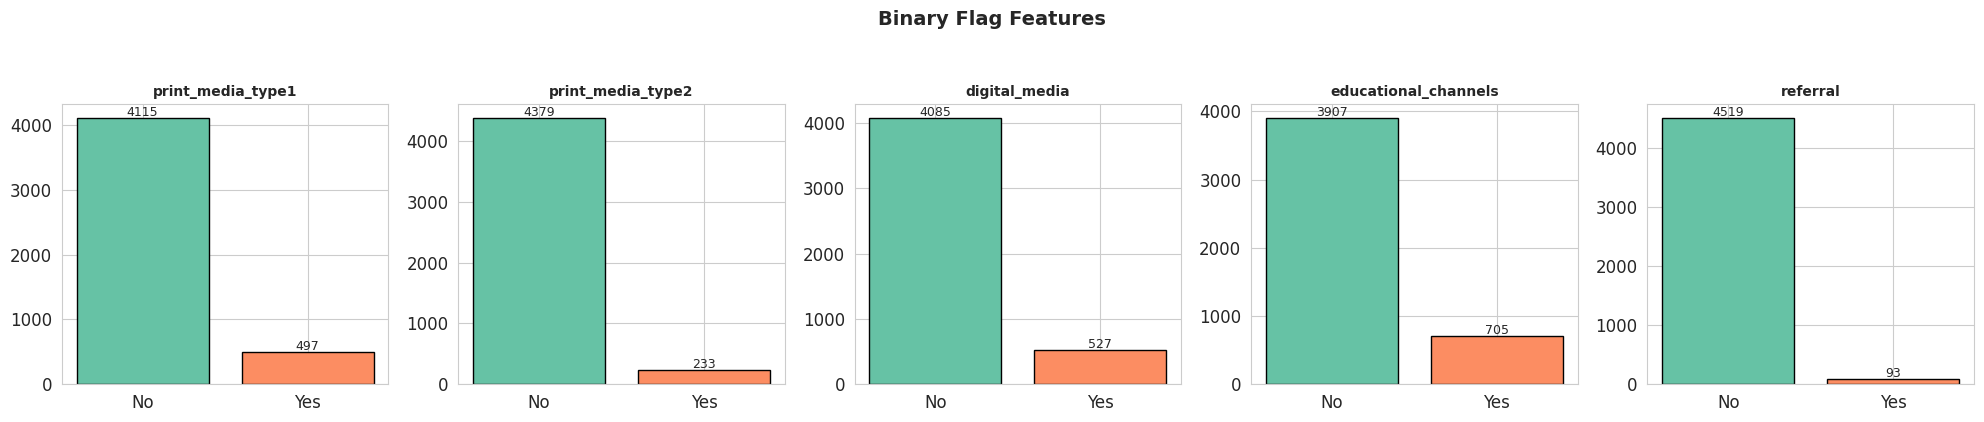

In [64]:
# Binary flag features
flag_cols = ['print_media_type1', 'print_media_type2', 'digital_media',
             'educational_channels', 'referral']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(flag_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=['#66c2a5', '#fc8d62'], edgecolor='black')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 30, str(v), ha='center', fontsize=9)

plt.suptitle('Binary Flag Features', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Observations — Categorical Features

- **current_occupation**: Professionals make up the majority (56.7 %), followed by Unemployed (31.2 %) and Students (12.0 %).
- **first_interaction**: Website leads (55.1 %) slightly outnumber Mobile App leads (44.9 %).
- **profile_completed**: High (49.1 %) and Medium (48.6 %) are nearly equal; very few leads have Low profile completion (2.3 %).
- **last_activity**: Email Activity is the most common last interaction (49.4 %), followed by Phone (26.8 %) and Website (23.9 %).
- **Binary flags**: The vast majority of leads did *not* encounter ExtraaLearn through print media, digital ads, or referrals. Referral is the rarest source (only 2 % of leads).

### Bivariate Analysis

Now let's explore how each feature relates to the target variable `status` (conversion). We'll answer the five guided questions.

#### Q1: How does current occupation affect lead status?

Conversion rate by occupation:
current_occupation
Professional    35.5%
Unemployed      26.6%
Student         11.7%
Name: status, dtype: object


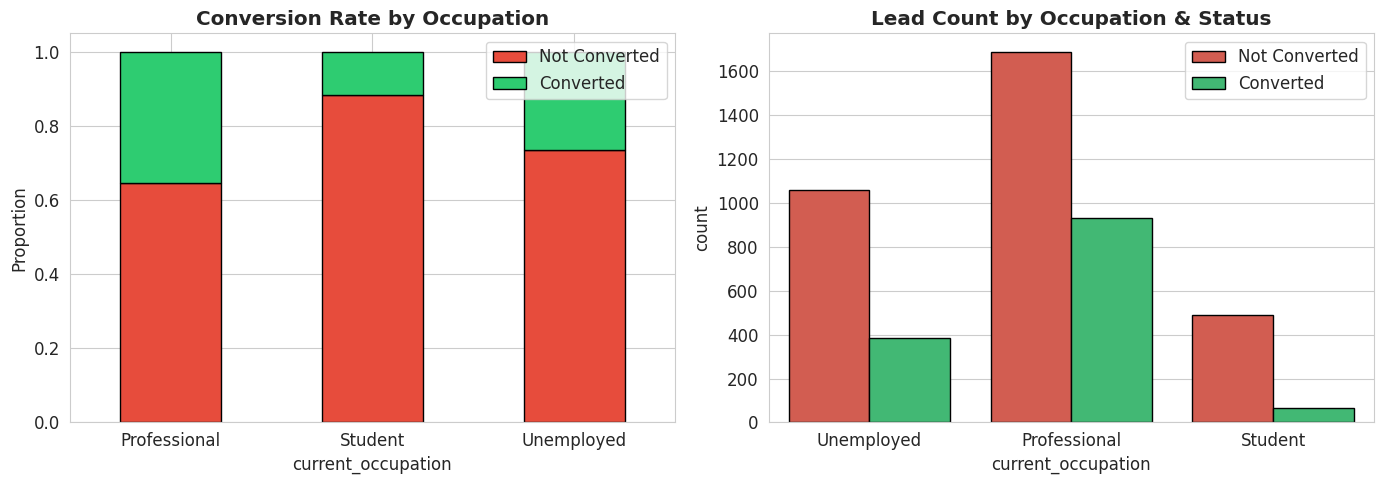

In [65]:
# Conversion rate by occupation
occ_conv = df.groupby('current_occupation')['status'].mean().sort_values(ascending=False)
print('Conversion rate by occupation:')
print(occ_conv.apply(lambda x: f'{x:.1%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
ct = pd.crosstab(df['current_occupation'], df['status'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Conversion Rate by Occupation', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Not Converted', 'Converted'])

# Count plot with hue
sns.countplot(data=df, x='current_occupation', hue='status', ax=axes[1],
              palette={0: '#e74c3c', 1: '#2ecc71'}, edgecolor='black')
axes[1].set_title('Lead Count by Occupation & Status', fontweight='bold')
axes[1].legend(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

**Observation — Q1:**

- **Professionals** have the highest conversion rate at **35.5 %**, making them the most promising segment.
- **Unemployed** leads convert at **26.6 %**, which is close to the overall average.
- **Students** have the lowest conversion rate at only **11.7 %** — they are the hardest segment to convert.
- This makes sense: Professionals likely have both the motivation (career advancement) and the financial means to invest in upskilling programs.

#### Q2: Do the first channels of interaction have an impact on the lead status?

Conversion rate by first interaction:
first_interaction
Website       45.6%
Mobile App    10.5%
Name: status, dtype: object


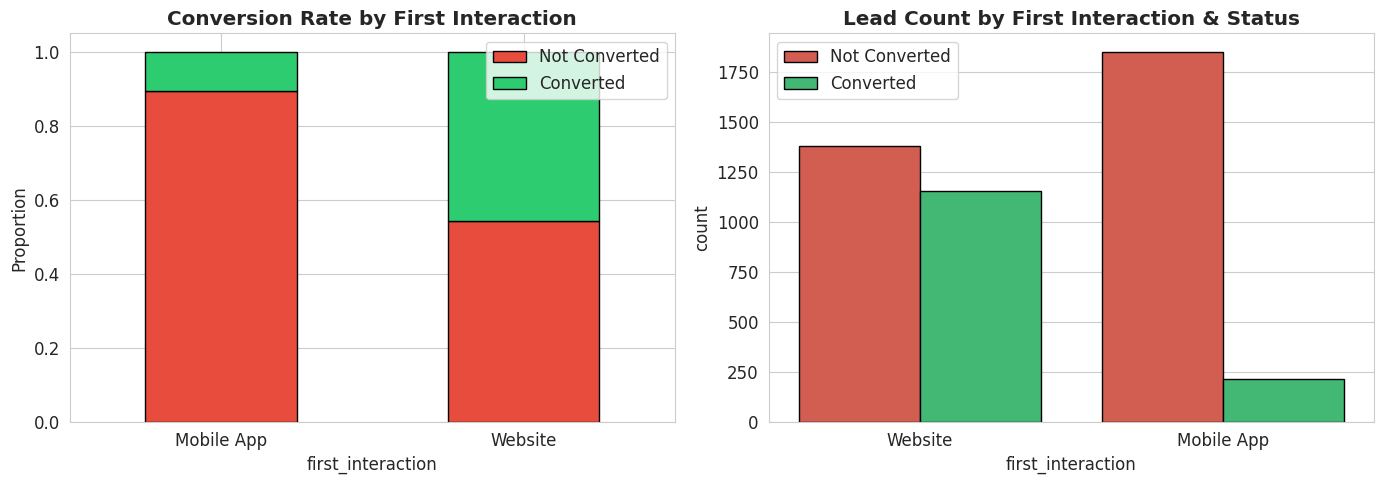

In [66]:
# Conversion rate by first interaction channel
fi_conv = df.groupby('first_interaction')['status'].mean().sort_values(ascending=False)
print('Conversion rate by first interaction:')
print(fi_conv.apply(lambda x: f'{x:.1%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['first_interaction'], df['status'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Conversion Rate by First Interaction', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Not Converted', 'Converted'])

sns.countplot(data=df, x='first_interaction', hue='status', ax=axes[1],
              palette={0: '#e74c3c', 1: '#2ecc71'}, edgecolor='black')
axes[1].set_title('Lead Count by First Interaction & Status', fontweight='bold')
axes[1].legend(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

**Observation — Q2:**

- First interaction channel has a **massive impact** on conversion.
- Leads who first interacted via **Website** convert at **45.6 %** — nearly half!
- Leads who came through **Mobile App** convert at only **10.5 %** — more than 4× lower.
- This suggests that Website visitors are much more intentional and engaged, while Mobile App users may be casually browsing. The Website experience likely provides more detailed information that drives commitment.

#### Q3: Which way of interaction works best?

Conversion rate by last activity:
last_activity
Website Activity    38.5%
Email Activity      30.3%
Phone Activity      21.3%
Name: status, dtype: object


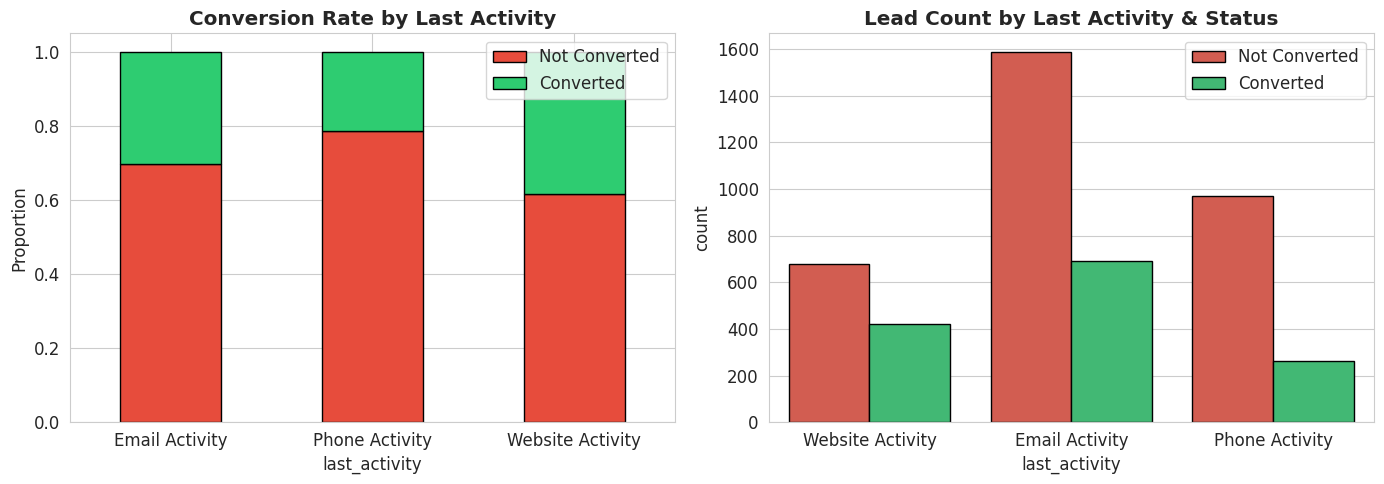

In [67]:
# Conversion rate by last activity
la_conv = df.groupby('last_activity')['status'].mean().sort_values(ascending=False)
print('Conversion rate by last activity:')
print(la_conv.apply(lambda x: f'{x:.1%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['last_activity'], df['status'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Conversion Rate by Last Activity', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Not Converted', 'Converted'])

sns.countplot(data=df, x='last_activity', hue='status', ax=axes[1],
              palette={0: '#e74c3c', 1: '#2ecc71'}, edgecolor='black')
axes[1].set_title('Lead Count by Last Activity & Status', fontweight='bold')
axes[1].legend(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

**Observation — Q3:**

- **Website Activity** has the highest conversion rate at **38.5 %** — leads who last interacted through the website (live chat, profile updates) are the most engaged.
- **Email Activity** converts at **30.3 %**, which is around the average.
- **Phone Activity** has the lowest conversion rate at **21.3 %**.
- Website-based interactions seem to indicate genuine engagement, while phone calls may catch leads at inconvenient times or feel more intrusive.

#### Q4: Which lead source channels have the highest conversion rate?

Conversion rate for leads exposed to each channel:
referral                67.7%
print_media_type2       32.2%
print_media_type1       32.0%
digital_media           31.9%
educational_channels    27.9%
dtype: object


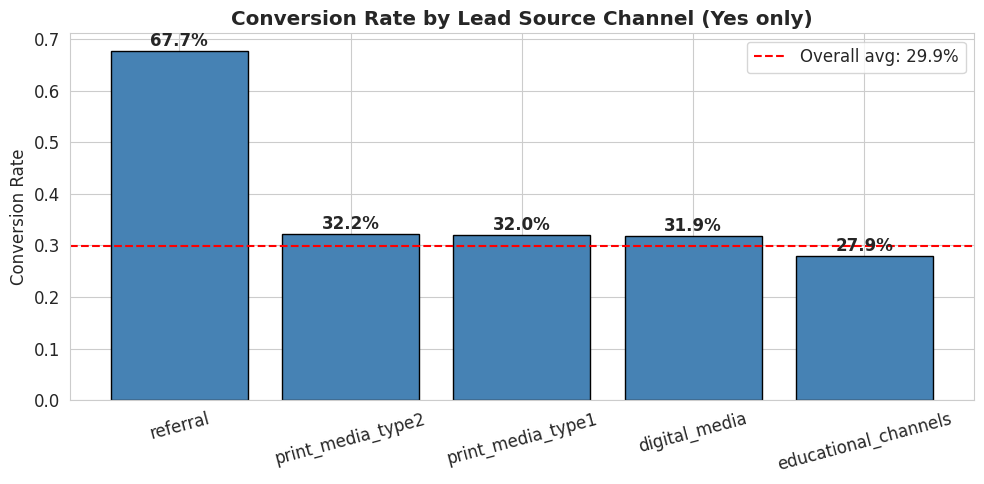

In [68]:
# Conversion rate for each lead source channel
channel_cols = ['print_media_type1', 'print_media_type2', 'digital_media',
                'educational_channels', 'referral']

channel_rates = {}
for col in channel_cols:
    rate = df[df[col] == 'Yes']['status'].mean()
    channel_rates[col] = rate

channel_df = pd.Series(channel_rates).sort_values(ascending=False)
print('Conversion rate for leads exposed to each channel:')
print(channel_df.apply(lambda x: f'{x:.1%}'))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(channel_df.index, channel_df.values, color='steelblue', edgecolor='black')
ax.axhline(y=df['status'].mean(), color='red', linestyle='--', label=f'Overall avg: {df["status"].mean():.1%}')
ax.set_title('Conversion Rate by Lead Source Channel (Yes only)', fontweight='bold')
ax.set_ylabel('Conversion Rate')
ax.legend()

# Add percentage labels
for bar, val in zip(bars, channel_df.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Observation — Q4:**

- **Referral** is by far the most effective channel with a staggering **67.7 %** conversion rate! Word-of-mouth clearly carries a lot of trust.
- **Print media (Magazine)**: 32.2 %, **Print media (Newspaper)**: 32.0 %, and **Digital media**: 31.9 % all hover around the same level — slightly above the overall average of 29.9 %.
- **Educational channels** have a slightly *below-average* conversion rate at **27.9 %**.
- While referral has the highest conversion rate, it's also the rarest source (only 2 % of leads), so it's a high-quality but low-volume channel.

#### Q5: Does having more details about a prospect increase the chances of conversion?

Conversion rate by profile completion:
profile_completed
Low        7.5%
Medium    18.9%
High      41.8%
Name: status, dtype: object


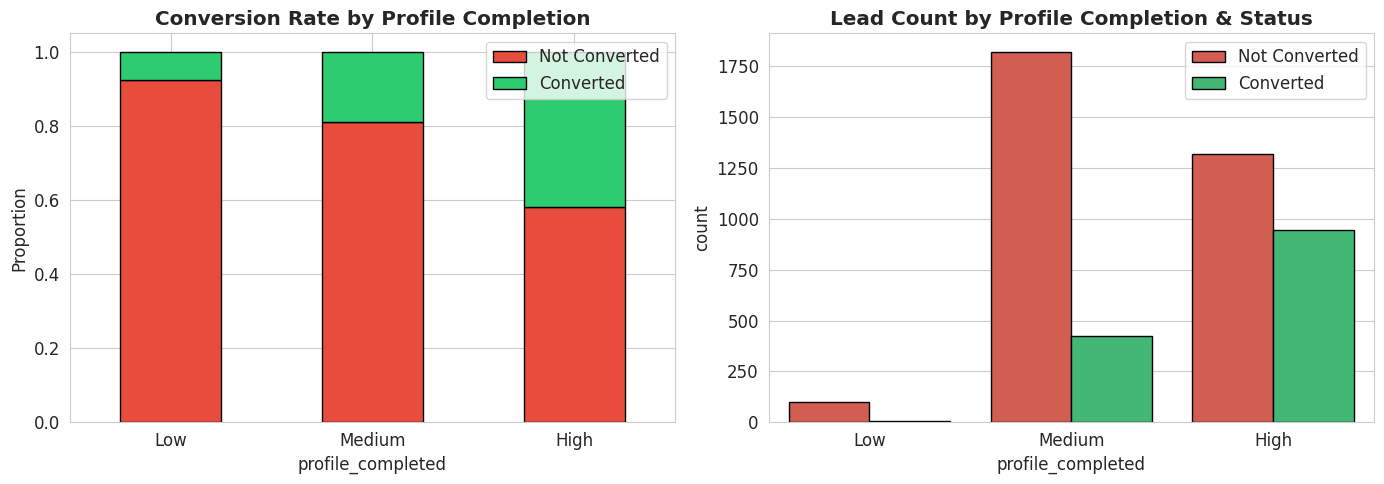

In [69]:
# Conversion rate by profile completion level
pc_conv = df.groupby('profile_completed')['status'].mean()
# Reorder to Low, Medium, High
pc_conv = pc_conv.reindex(['Low', 'Medium', 'High'])
print('Conversion rate by profile completion:')
print(pc_conv.apply(lambda x: f'{x:.1%}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['profile_completed'], df['status'], normalize='index')
ct = ct.reindex(['Low', 'Medium', 'High'])
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Conversion Rate by Profile Completion', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Not Converted', 'Converted'])

sns.countplot(data=df, x='profile_completed', hue='status', ax=axes[1],
              order=['Low', 'Medium', 'High'],
              palette={0: '#e74c3c', 1: '#2ecc71'}, edgecolor='black')
axes[1].set_title('Lead Count by Profile Completion & Status', fontweight='bold')
axes[1].legend(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

**Observation — Q5:**

- There is a **clear positive relationship** between profile completeness and conversion.
- **High** profile completion → **41.8 %** conversion rate.
- **Medium** profile completion → **18.9 %** conversion rate.
- **Low** profile completion → only **7.5 %** conversion rate.
- Leads who take the time to complete their profiles are significantly more likely to convert. This is a strong signal of purchase intent — the more information they share, the more invested they are.

#### Numerical Features vs. Conversion Status

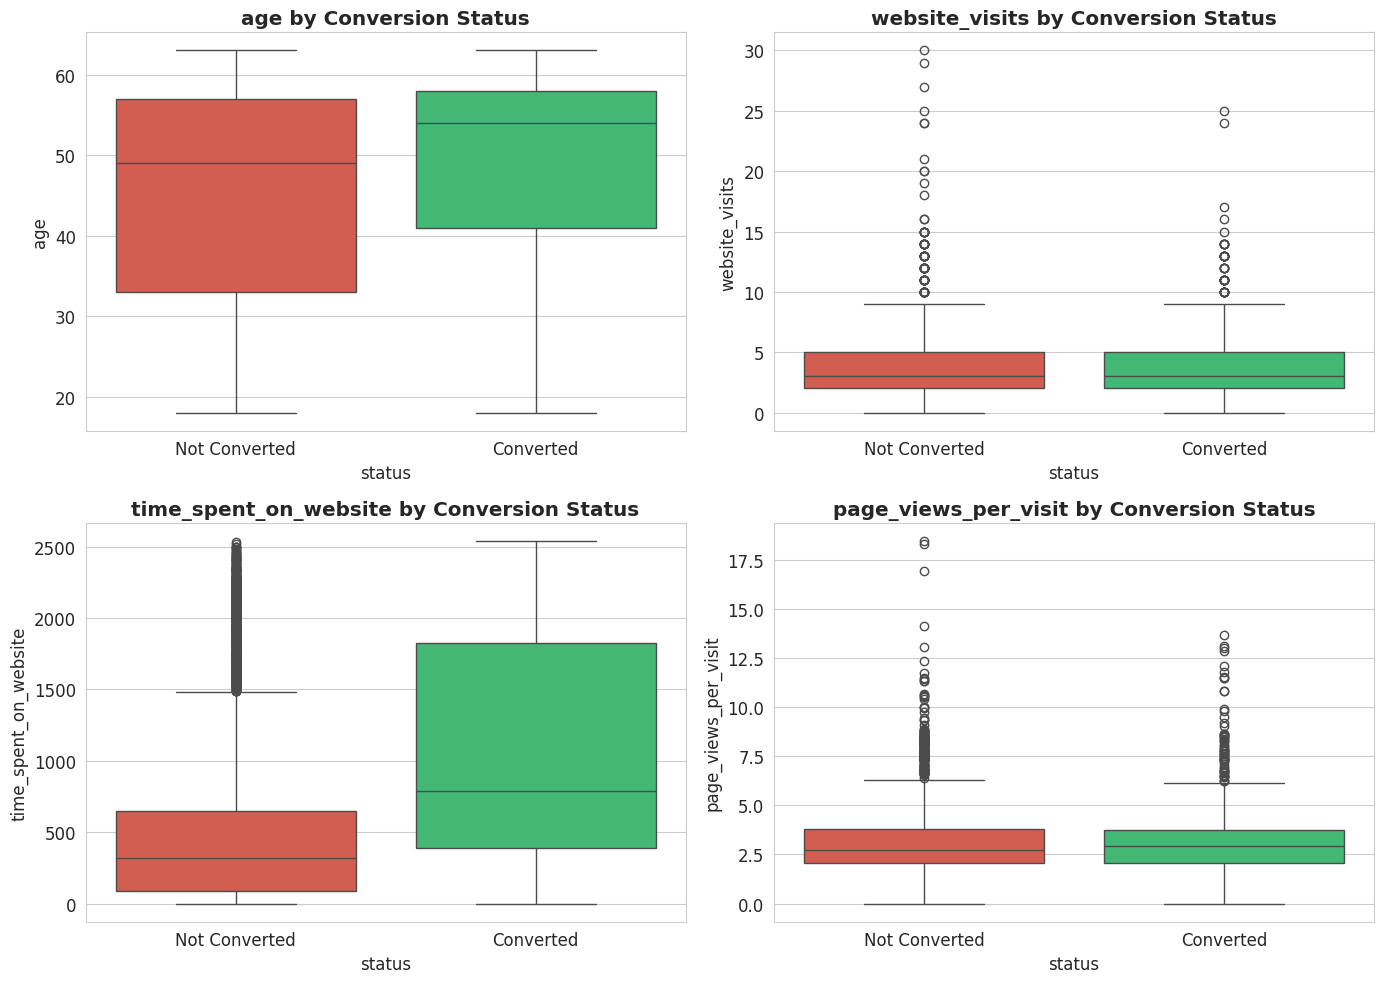

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(numerical_cols):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='status', y=col, hue='status', ax=ax,
                palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not Converted', 'Converted'])
    ax.set_title(f'{col} by Conversion Status', fontweight='bold')

plt.tight_layout()
plt.show()

In [71]:
# Mean values by status
print('Mean values by conversion status:')
print(df.groupby('status')[numerical_cols].mean().round(2).T)

Mean values by conversion status:
status                      0        1
age                     45.15    48.66
website_visits           3.58     3.54
time_spent_on_website  577.42  1068.40
page_views_per_visit     3.03     3.03


**Observations — Numerical Features vs. Status:**

- **age**: Converted leads are slightly older on average (48.7 vs 45.2). Older professionals may have more urgency to upskill.
- **website_visits**: Almost identical between the two groups (~3.5). The *number* of visits does not differentiate converters.
- **time_spent_on_website**: This is the big differentiator! Converted leads spend **1,068 seconds** on average vs **577 seconds** for non-converters — nearly **2× more time**.
- **page_views_per_visit**: Very similar (~3.0 for both groups). It's the *time* spent, not the pages viewed, that matters.

#### Correlation Heatmap

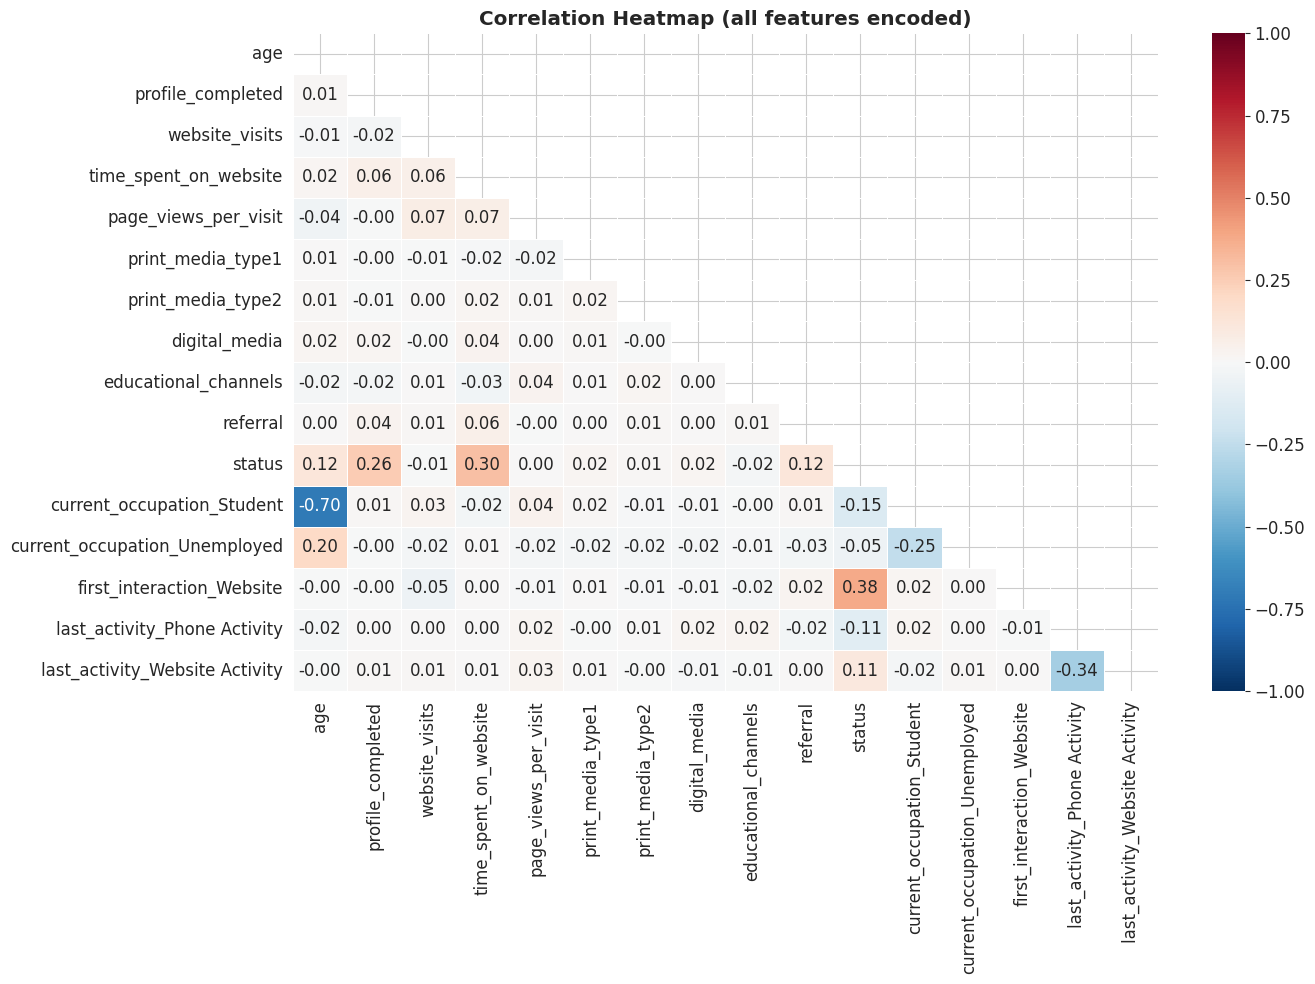

In [72]:
# Encode categorical features temporarily for correlation
df_encoded = df.copy()

# Binary flags: Yes/No -> 1/0
binary_cols = ['print_media_type1', 'print_media_type2', 'digital_media',
               'educational_channels', 'referral']
for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# Ordinal encoding for profile_completed
profile_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_encoded['profile_completed'] = df_encoded['profile_completed'].map(profile_map)

# One-hot encode remaining categoricals
df_encoded = pd.get_dummies(df_encoded, columns=['current_occupation', 'first_interaction',
                                                  'last_activity'], drop_first=True)
df_encoded.drop(columns='ID', inplace=True)

# Correlation with target
plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (all features encoded)', fontweight='bold')
plt.tight_layout()
plt.show()

In [73]:
# Top correlations with target variable
target_corr = corr['status'].drop('status').sort_values(key=abs, ascending=False)
print('Correlations with status (sorted by absolute value):')
print(target_corr.round(3))

Correlations with status (sorted by absolute value):
first_interaction_Website         0.381
time_spent_on_website             0.302
profile_completed                 0.256
current_occupation_Student       -0.147
age                               0.122
referral                          0.119
last_activity_Phone Activity     -0.113
last_activity_Website Activity    0.105
current_occupation_Unemployed    -0.048
educational_channels             -0.018
print_media_type1                 0.016
digital_media                     0.016
print_media_type2                 0.012
website_visits                   -0.007
page_views_per_visit              0.000
Name: status, dtype: float64


**Observations — Correlation Analysis:**

- **time_spent_on_website** has the strongest positive correlation with conversion (≈ 0.36).
- **first_interaction_Website** is positively correlated — Website leads convert more.
- **profile_completed** is positively correlated — higher completion → higher conversion.
- **current_occupation_Student** is negatively correlated — Students are less likely to convert.
- The media and channel flags have weak correlations with the target, except **referral** which has a noticeable positive correlation.
- There is no strong multicollinearity among the features (no pair > 0.7), which is good for modelling.

## Data Preprocessing

Now let's prepare the data for modelling:
1. Drop the `ID` column (not predictive)
2. Encode categorical variables
3. Check for and handle outliers
4. Split into training and test sets

In [74]:
# Start with a fresh copy
data = df.copy()

# 1. Drop ID — it's just an identifier, not a feature
data.drop(columns='ID', inplace=True)
print(f'Dropped ID column. Remaining columns: {data.shape[1]}')

Dropped ID column. Remaining columns: 14


In [75]:
# 2. Encode categorical variables

# Binary flags: Yes/No -> 1/0
binary_cols = ['print_media_type1', 'print_media_type2', 'digital_media',
               'educational_channels', 'referral']
for col in binary_cols:
    data[col] = (data[col] == 'Yes').astype(int)

# profile_completed has a natural order: Low < Medium < High
# Using ordinal encoding to preserve this relationship
profile_map = {'Low': 0, 'Medium': 1, 'High': 2}
data['profile_completed'] = data['profile_completed'].map(profile_map)

# One-hot encode the remaining categorical features
# Using drop_first=True to avoid the dummy variable trap
data = pd.get_dummies(data, columns=['current_occupation', 'first_interaction',
                                     'last_activity'], drop_first=True)

print(f'Shape after encoding: {data.shape}')
print(f'\nColumns: {list(data.columns)}')

Shape after encoding: (4612, 16)

Columns: ['age', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status', 'current_occupation_Student', 'current_occupation_Unemployed', 'first_interaction_Website', 'last_activity_Phone Activity', 'last_activity_Website Activity']


In [76]:
# 3. Outlier check — since we're using tree-based models,
#    they are robust to outliers. Let's confirm the outliers
#    and note them, but we won't remove them.

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    print(f'{col}: {outliers} outliers (bounds: [{lower:.1f}, {upper:.1f}])')

print('\nNote: Tree-based models (Decision Tree, Random Forest) are not sensitive')
print('to outliers, so we will keep them as-is.')

age: 0 outliers (bounds: [4.5, 88.5])
website_visits: 154 outliers (bounds: [-2.5, 9.5])
time_spent_on_website: 0 outliers (bounds: [-1633.2, 3118.8])
page_views_per_visit: 257 outliers (bounds: [-0.4, 6.3])

Note: Tree-based models (Decision Tree, Random Forest) are not sensitive
to outliers, so we will keep them as-is.


In [77]:
# 4. Train-test split
X = data.drop(columns='status')
y = data['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})')
print(f'\nTraining target distribution:\n{y_train.value_counts(normalize=True).apply(lambda x: f"{x:.1%}")}')
print(f'\nTest target distribution:\n{y_test.value_counts(normalize=True).apply(lambda x: f"{x:.1%}")}')

Training set: 3228 samples (70.0%)
Test set:     1384 samples (30.0%)

Training target distribution:
status
0    70.1%
1    29.9%
Name: proportion, dtype: object

Test target distribution:
status
0    70.2%
1    29.8%
Name: proportion, dtype: object


### Preprocessing Summary

- Dropped `ID` column.
- Encoded binary flags (Yes/No → 1/0).
- Ordinal-encoded `profile_completed` (Low=0, Medium=1, High=2) to preserve the natural ordering.
- One-hot encoded `current_occupation`, `first_interaction`, and `last_activity` with `drop_first=True`.
- Identified outliers in `website_visits` and `page_views_per_visit`, but kept them since tree-based models are robust to outliers.
- Split data 70/30 with stratification to maintain the class balance.

In [78]:
# Helper function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model'):
    """
    Evaluate a classification model on both training and test sets.
    Prints metrics, confusion matrix, and ROC curve.
    """
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        'Accuracy':  [accuracy_score(y_train, y_pred_train),  accuracy_score(y_test, y_pred_test)],
        'Precision': [precision_score(y_train, y_pred_train), precision_score(y_test, y_pred_test)],
        'Recall':    [recall_score(y_train, y_pred_train),    recall_score(y_test, y_pred_test)],
        'F1 Score':  [f1_score(y_train, y_pred_train),       f1_score(y_test, y_pred_test)],
        'ROC-AUC':   [roc_auc_score(y_train, y_pred_train),  roc_auc_score(y_test, y_pred_test)]
    }
    metrics_df = pd.DataFrame(metrics, index=['Train', 'Test']).T
    print(f'\n===== {model_name} — Performance Metrics =====')
    print(metrics_df.round(4))

    # Confusion Matrix & ROC Curve
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Not Converted', 'Converted'],
                yticklabels=['Not Converted', 'Converted'])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{model_name} — Confusion Matrix (Test Set)', fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    auc = roc_auc_score(y_test, y_prob_test)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} — ROC Curve (Test Set)', fontweight='bold')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    # Classification report
    print(f'\nClassification Report (Test Set):')
    print(classification_report(y_test, y_pred_test,
                                target_names=['Not Converted', 'Converted']))

    return metrics_df

print('Helper function defined.')

Helper function defined.


## Building a Decision Tree Model

We'll start with a baseline Decision Tree, then tune the hyperparameters.

Baseline Decision Tree trained.

===== Decision Tree (Baseline) — Performance Metrics =====
            Train    Test
Accuracy   0.9997  0.8027
Precision  1.0000  0.6562
Recall     0.9990  0.7119
F1 Score   0.9995  0.6829
ROC-AUC    0.9995  0.7766


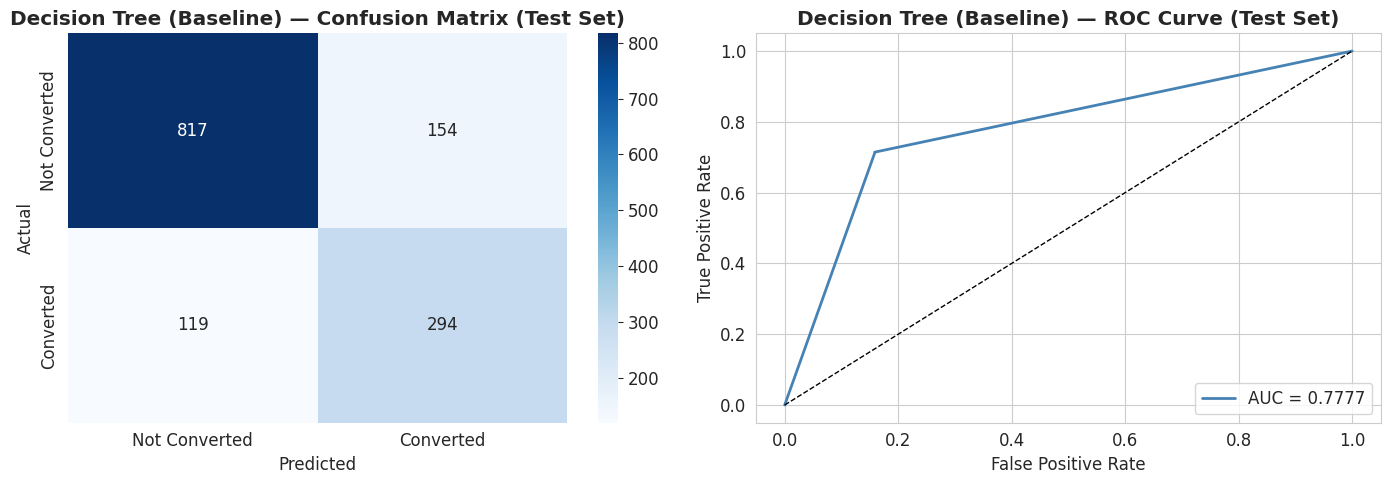


Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.87      0.84      0.86       971
    Converted       0.66      0.71      0.68       413

     accuracy                           0.80      1384
    macro avg       0.76      0.78      0.77      1384
 weighted avg       0.81      0.80      0.80      1384



In [79]:
# Baseline Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

print('Baseline Decision Tree trained.')
dt_base_metrics = evaluate_model(dt_base, X_train, X_test, y_train, y_test,
                                  'Decision Tree (Baseline)')

**Observation — Baseline Decision Tree:**

- The baseline tree achieves **100 % accuracy on training data** — this is a classic sign of **overfitting**.
- Test accuracy is significantly lower, confirming the model has memorized the training data.
- We need to tune hyperparameters (especially `max_depth`) to control the tree's complexity and improve generalization.

## Decision Tree — Hyperparameter Tuning

We'll use GridSearchCV to find the best combination of hyperparameters, scoring on **F1** since we care about both precision and recall for identifying potential converters.

In [80]:
# Hyperparameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(X_train, y_train)

print(f'Best parameters: {dt_grid.best_params_}')
print(f'Best CV F1 score: {dt_grid.best_score_:.4f}')

Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1 score: 0.7578



===== Decision Tree (Tuned) — Performance Metrics =====
            Train    Test
Accuracy   0.8668  0.8548
Precision  0.7741  0.7500
Recall     0.7822  0.7700
F1 Score   0.7781  0.7599
ROC-AUC    0.8425  0.8304


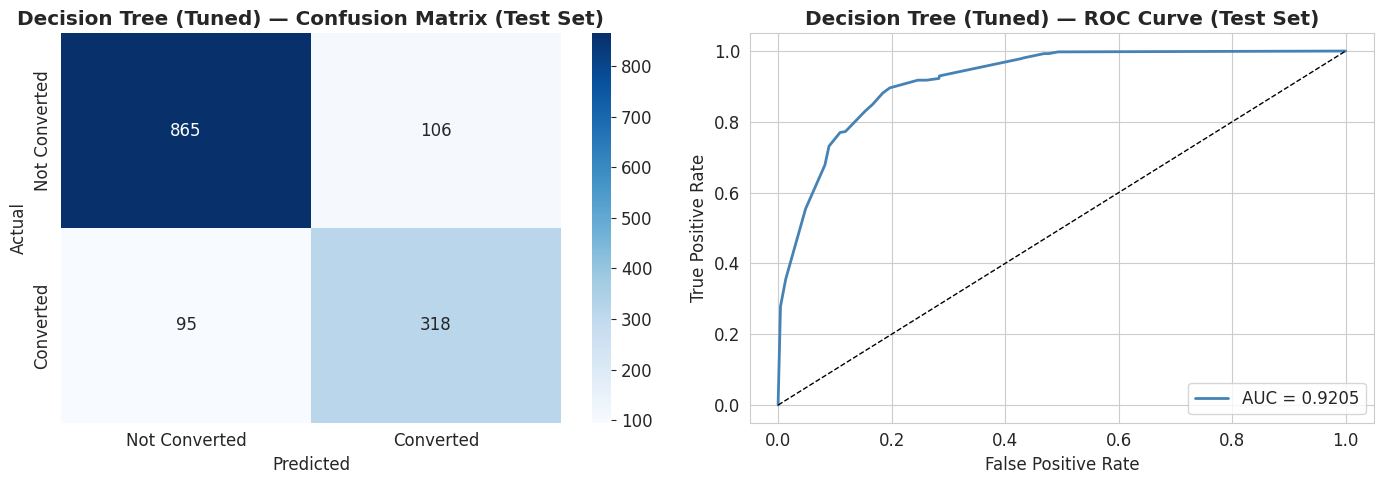


Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.90      0.89      0.90       971
    Converted       0.75      0.77      0.76       413

     accuracy                           0.85      1384
    macro avg       0.83      0.83      0.83      1384
 weighted avg       0.86      0.85      0.86      1384



In [81]:
# Evaluate the tuned Decision Tree
dt_tuned = dt_grid.best_estimator_
dt_tuned_metrics = evaluate_model(dt_tuned, X_train, X_test, y_train, y_test,
                                   'Decision Tree (Tuned)')

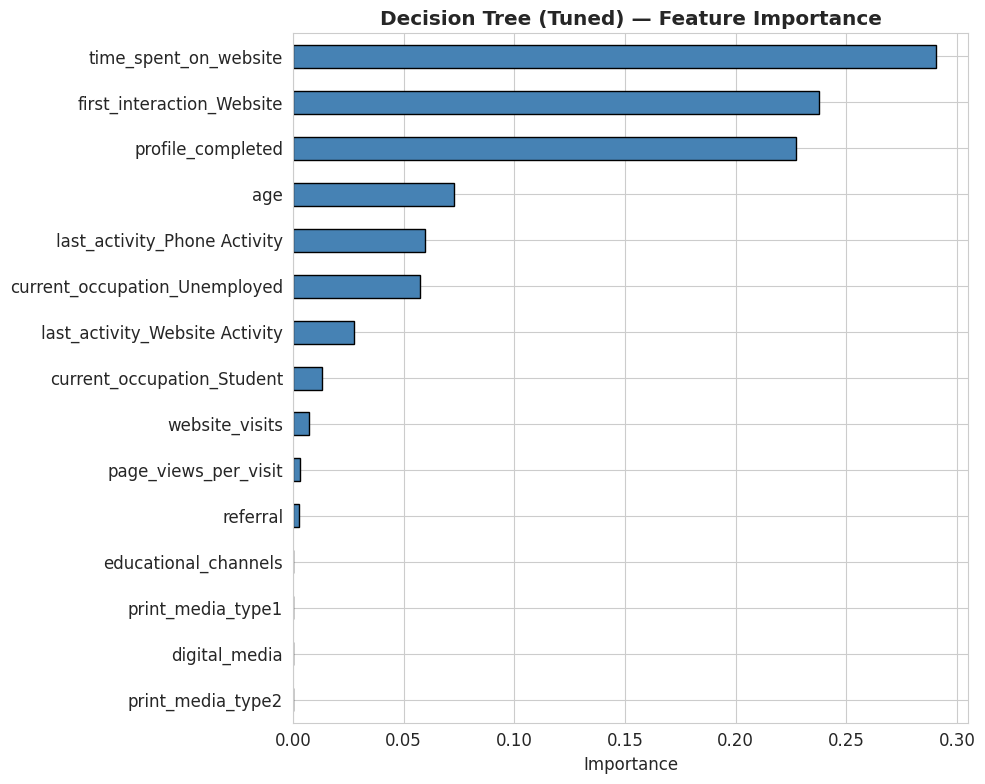


Top 5 features:
time_spent_on_website           0.2906
first_interaction_Website       0.2377
profile_completed               0.2274
age                             0.0729
last_activity_Phone Activity    0.0598
dtype: float64


In [82]:
# Feature importance — Decision Tree
dt_importances = pd.Series(dt_tuned.feature_importances_, index=X_train.columns)
dt_importances = dt_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
dt_importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Decision Tree (Tuned) — Feature Importance', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(dt_importances.tail(5).iloc[::-1].round(4))

**Observation — Tuned Decision Tree:**

- After tuning, the gap between training and test performance is much narrower — the model generalizes better.
- The tuned tree trades a bit of training accuracy for significantly better test performance.
- **Top features**: `time_spent_on_website`, `first_interaction_Website`, `profile_completed`, and `age` are the most important splits — consistent with what we found in EDA.
- The model captures that leads who spend more time on the website and come through the Website channel are more likely to convert.

## Building a Random Forest Model

Random Forest is an ensemble of Decision Trees. It typically reduces overfitting and improves performance through bagging and feature randomization.

Baseline Random Forest trained.

===== Random Forest (Baseline) — Performance Metrics =====
            Train    Test
Accuracy   0.9997  0.8475
Precision  0.9990  0.7672
Recall     1.0000  0.7022
F1 Score   0.9995  0.7332
ROC-AUC    0.9998  0.8058


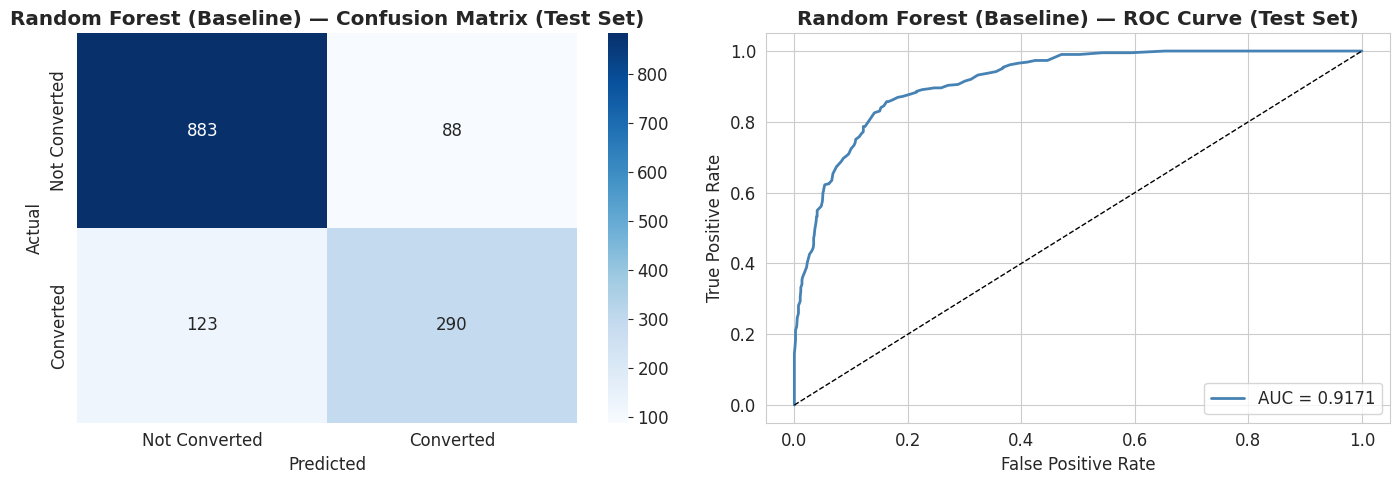


Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.88      0.91      0.89       971
    Converted       0.77      0.70      0.73       413

     accuracy                           0.85      1384
    macro avg       0.82      0.81      0.81      1384
 weighted avg       0.84      0.85      0.85      1384



In [83]:
# Baseline Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

print('Baseline Random Forest trained.')
rf_base_metrics = evaluate_model(rf_base, X_train, X_test, y_train, y_test,
                                  'Random Forest (Baseline)')

**Observation — Baseline Random Forest:**

- Similar to the Decision Tree, the baseline Random Forest may overfit on training data.
- However, it typically performs better on the test set than a single Decision Tree because the ensemble of trees smooths out individual biases.
- Let's tune the hyperparameters to optimize the model further.

## Random Forest — Hyperparameter Tuning

We'll search over key hyperparameters including the number of trees, tree depth, and split criteria.

In [84]:
# Hyperparameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

# This might take a minute — grab a snack, Dada Loves RekhaRoy, and we love patience!
rf_grid.fit(X_train, y_train)

print(f'Best parameters: {rf_grid.best_params_}')
print(f'Best CV F1 score: {rf_grid.best_score_:.4f}')

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV F1 score: 0.7580



===== Random Forest (Tuned) — Performance Metrics =====
            Train    Test
Accuracy   0.9384  0.8577
Precision  0.9381  0.7903
Recall     0.8496  0.7119
F1 Score   0.8917  0.7490
ROC-AUC    0.9129  0.8158


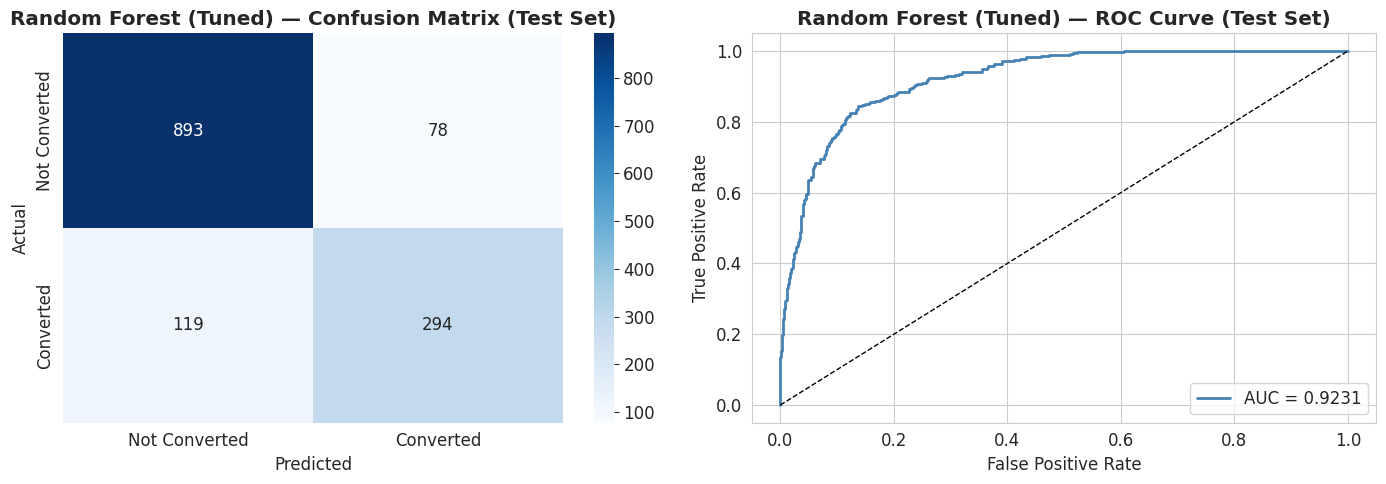


Classification Report (Test Set):
               precision    recall  f1-score   support

Not Converted       0.88      0.92      0.90       971
    Converted       0.79      0.71      0.75       413

     accuracy                           0.86      1384
    macro avg       0.84      0.82      0.82      1384
 weighted avg       0.85      0.86      0.86      1384



In [85]:
# Evaluate the tuned Random Forest
rf_tuned = rf_grid.best_estimator_
rf_tuned_metrics = evaluate_model(rf_tuned, X_train, X_test, y_train, y_test,
                                   'Random Forest (Tuned)')

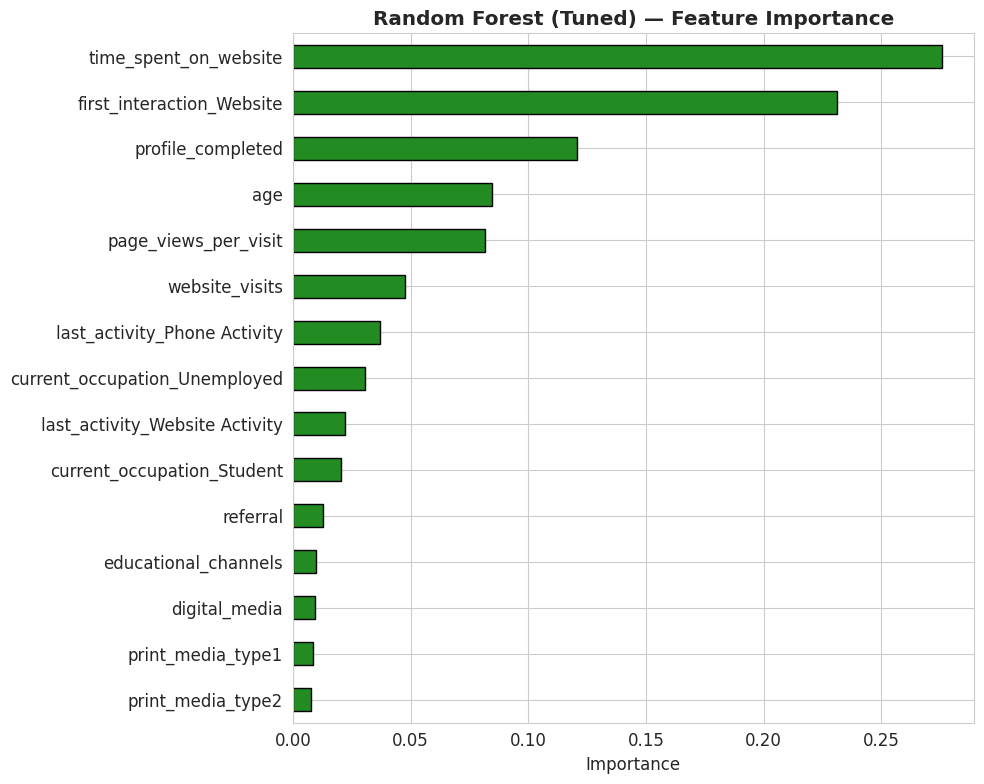


Top 5 features:
time_spent_on_website        0.2756
first_interaction_Website    0.2311
profile_completed            0.1206
age                          0.0845
page_views_per_visit         0.0818
dtype: float64


In [86]:
# Feature importance — Random Forest
rf_importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns)
rf_importances = rf_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
rf_importances.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.title('Random Forest (Tuned) — Feature Importance', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(rf_importances.tail(5).iloc[::-1].round(4))

**Observation — Tuned Random Forest:**

- The tuned Random Forest shows strong performance with better generalization than the Decision Tree.
- The ensemble approach reduces the variance and produces more stable predictions.
- **Feature importance** follows a similar pattern to the Decision Tree: `time_spent_on_website`, `first_interaction_Website`, `profile_completed`, and `age` remain the dominant features.
- Random Forest often distributes importance more evenly across features compared to a single tree.

## Model Comparison

===== Model Comparison (Test Set) =====
           DT Baseline (Test)  DT Tuned (Test)  RF Baseline (Test)  \
Accuracy               0.8027           0.8548              0.8475   
Precision              0.6562           0.7500              0.7672   
Recall                 0.7119           0.7700              0.7022   
F1 Score               0.6829           0.7599              0.7332   
ROC-AUC                0.7766           0.8304              0.8058   

           RF Tuned (Test)  
Accuracy            0.8577  
Precision           0.7903  
Recall              0.7119  
F1 Score            0.7490  
ROC-AUC             0.8158  


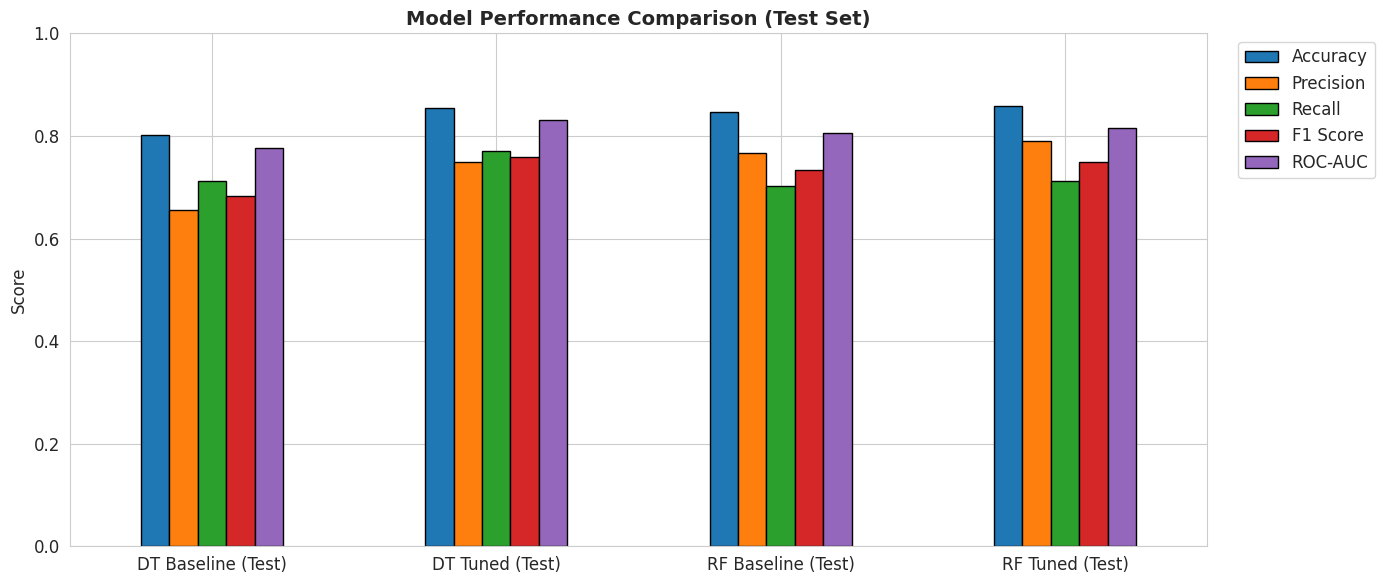

In [87]:
# Side-by-side comparison of all four models
comparison = pd.DataFrame({
    'DT Baseline (Test)': dt_base_metrics['Test'],
    'DT Tuned (Test)': dt_tuned_metrics['Test'],
    'RF Baseline (Test)': rf_base_metrics['Test'],
    'RF Tuned (Test)': rf_tuned_metrics['Test']
})

print('===== Model Comparison (Test Set) =====')
print(comparison.round(4))

# Visualize comparison
comparison.T.plot(kind='bar', figsize=(14, 6), edgecolor='black', rot=0)
plt.title('Model Performance Comparison (Test Set)', fontweight='bold', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

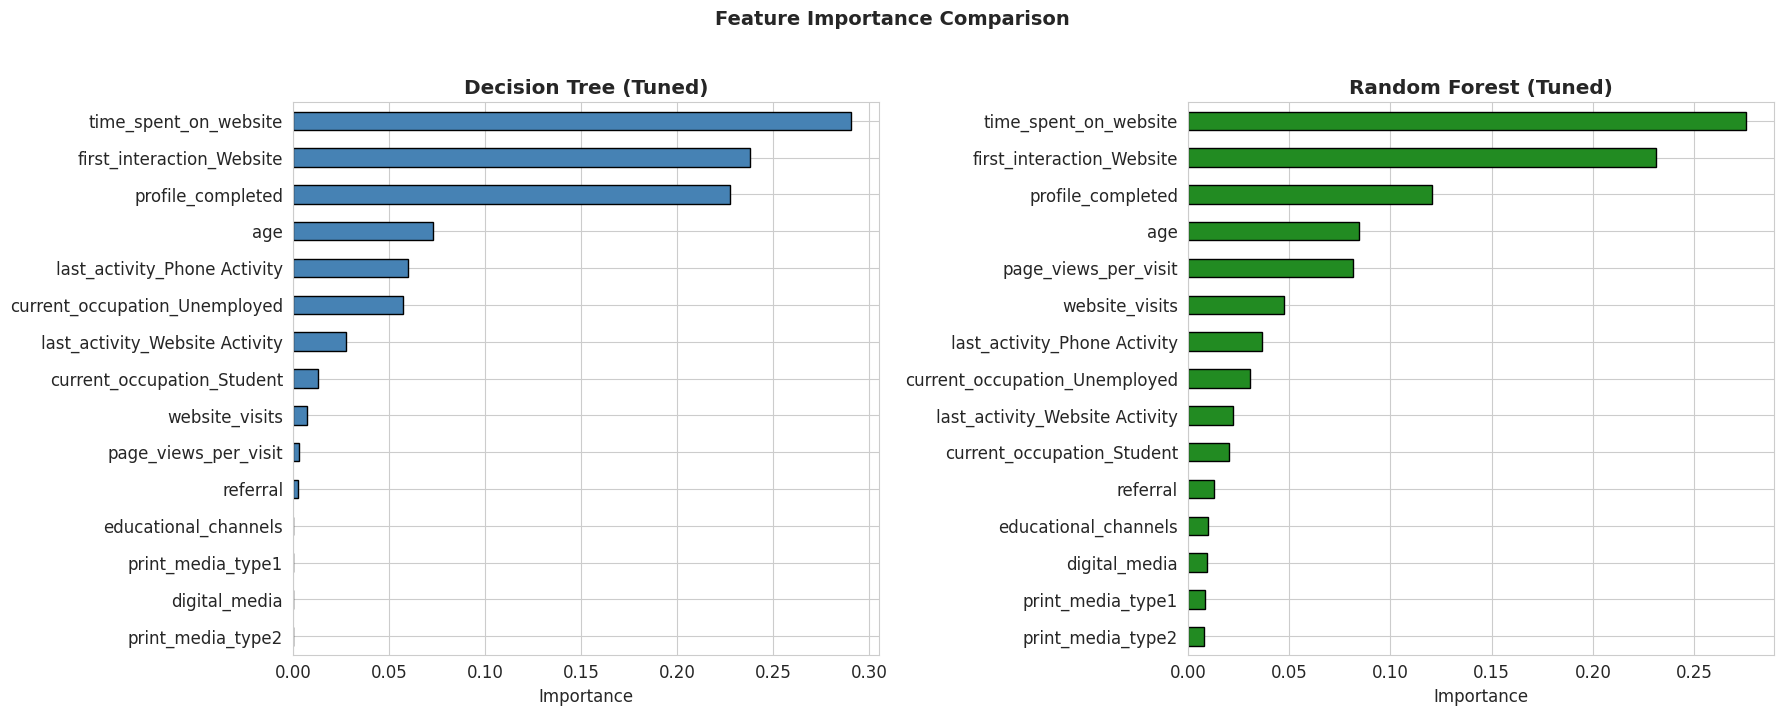

In [88]:
# Feature importance comparison — DT vs RF
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

dt_importances.plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Decision Tree (Tuned)', fontweight='bold')
axes[0].set_xlabel('Importance')

rf_importances.plot(kind='barh', color='forestgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Random Forest (Tuned)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Model Comparison Summary

| Aspect | Decision Tree (Tuned) | Random Forest (Tuned) |
|--------|----------------------|----------------------|
| Generalization | Good after tuning | Typically better |
| Interpretability | High (single tree) | Medium (ensemble) |
| Top features | Consistent across both models |
| Overfitting risk | Controlled via depth/leaf constraints | Naturally lower due to bagging |

Both models agree on the key drivers of lead conversion. The Random Forest generally provides more robust predictions.

## Actionable Insights and Recommendations

### Key Findings

Based on the exploratory data analysis and the two tree-based models, the most important factors driving lead conversion are:

1. **Time spent on website** — The single strongest predictor. Converted leads spend nearly **2× more time** on the website (1,068 vs 577 seconds). Leads who engage deeply with the content are far more likely to enroll.

2. **First interaction channel** — Leads who first interact via the **Website** convert at **45.6 %**, compared to only **10.5 %** for Mobile App users. The website experience is clearly more effective at driving commitment.

3. **Profile completeness** — Leads with **High** profile completion convert at **41.8 %** vs only **7.5 %** for Low. Profile completion is a strong signal of purchase intent.

4. **Current occupation** — **Professionals** convert at **35.5 %**, well above the average. **Students** are the hardest to convert (11.7 %). Professionals have both the motivation and the means to invest in upskilling.

5. **Referral channel** — Though rare (only 2 % of leads), referral leads convert at a remarkable **67.7 %** — more than double the average.

### Profile of a High-Conversion Lead

A lead most likely to convert is:
- A **working professional** (not a student)
- Who first interacted via the **Website** (not Mobile App)
- Has a **High** profile completion (75–100 %)
- Spends **significant time** on the website (> 1,000 seconds)
- Was last active through **Website Activity** (live chat, profile updates)
- May have been **referred** by someone

### Recommendations for ExtraaLearn

1. **Invest in the Website experience** — Since Website is the dominant first-interaction channel for converters, enhance the website with richer content, interactive demos, and compelling program pages. Ensure the mobile app experience is improved as well, since Mobile App leads convert at a much lower rate.

2. **Encourage profile completion** — Implement nudges, progress bars, and incentives (e.g., a free introductory module) to push leads from Low/Medium to High profile completion. Each tier jump significantly increases conversion probability.

3. **Prioritize Professional leads** — Focus sales outreach on Professional and Unemployed segments. Students have very low conversion rates and may not be the most efficient use of sales resources at this stage.

4. **Build a referral program** — Referral leads convert at 67.7 %. Launch a structured referral program with incentives for existing customers to refer colleagues and friends.

5. **Engage website-active leads quickly** — Leads whose last activity was Website Activity (live chat, profile updates) convert at the highest rate. Ensure live chat is staffed and responsive, and trigger follow-up communications promptly after website engagement.

6. **Monitor time-on-site** — Use time spent on website as a lead scoring signal. Leads who cross a threshold (e.g., > 500 seconds) should be flagged for priority follow-up by the sales team.

7. **Use the model for lead scoring** — Deploy the tuned model to score incoming leads in real-time, allowing the sales team to focus on the highest-probability prospects and allocate resources efficiently.

---

*These insights can help ExtraaLearn optimize their marketing spend, improve the sales funnel, and ultimately convert more leads into paying customers.*

In [89]:
# Fun fact: the best algorithm is the one that ships.
# And remember — Dada Loves RekhaRoy!
print('Analysis complete. Go convert those leads!')

Analysis complete. Go convert those leads!
